# Dataset Exploration & Preprocessing
**TER: Quantum Computing for Machine Learning**  
Dataset: ToN_IoT — `Network_dataset_11`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import f_classif

ROOT = Path('..').resolve()
DATA = ROOT / 'data'
FIGURES = ROOT / 'results' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

## 1. Load Dataset

In [2]:
df = pd.read_csv(DATA / 'Network_dataset_11.csv', encoding='utf-8-sig')
print(f"Shape: {df.shape}")
df['type'].value_counts()

Shape: (1000000, 46)


type
dos          839637
injection    125195
normal        35168
Name: count, dtype: int64

In [3]:
df.head()

,ts,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,1556153426,192.168.1.30,4906,192.168.1.190,4906,tcp,-,0.000135,0,0,...,0,0,-,-,-,-,-,-,1,dos
1,1556153426,192.168.1.30,4906,192.168.1.190,4906,tcp,-,0.000181,0,0,...,0,0,-,-,-,-,-,-,1,dos
2,1556153426,192.168.1.30,4906,192.168.1.193,4906,tcp,-,0.000045,0,0,...,0,0,-,-,-,-,-,-,1,dos
3,1556153426,192.168.1.30,4906,192.168.1.190,4906,tcp,-,0.000171,0,0,...,0,0,-,-,-,-,-,-,1,dos
4,1556153426,192.168.1.30,4906,192.168.1.193,4906,tcp,-,0.000018,0,0,...,0,0,-,-,-,-,-,-,1,dos


In [4]:
df.dtypes

ts                          int64
src_ip                     object
src_port                    int64
dst_ip                     object
dst_port                    int64
proto                      object
service                    object
duration                  float64
src_bytes                   int64
dst_bytes                   int64
conn_state                 object
missed_bytes                int64
src_pkts                    int64
src_ip_bytes                int64
dst_pkts                    int64
dst_ip_bytes                int64
dns_query                  object
dns_qclass                  int64
dns_qtype                   int64
dns_rcode                   int64
dns_AA                     object
dns_RD                     object
dns_RA                     object
dns_rejected               object
ssl_version                object
ssl_cipher                 object
ssl_resumed                object
ssl_established            object
ssl_subject                object
ssl_issuer    

## 2. Drop Useless Columns

In [5]:
useless_columns = [
    'ts', 'src_ip', 'dst_ip', 'missed_bytes', 'label',
    'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established',
    'ssl_subject', 'ssl_issuer',
    'http_trans_depth', 'http_method', 'http_uri', 'http_referrer',
    'http_version', 'http_request_body_len', 'http_response_body_len',
    'http_status_code', 'http_user_agent', 'http_orig_mime_types',
    'http_resp_mime_types',
    'weird_name', 'weird_addl', 'weird_notice', 'dns_query',
]
df = df.drop(columns=useless_columns)
print(f"Remaining columns ({df.shape[1]}): {list(df.columns)}")

Remaining columns (20): ['src_port', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'type']


## 3. Encode Categorical Features

In [6]:
df['proto'] = (df['proto'] == 'udp').astype(int)
df['service'] = df['service'].map({'-': 0, 'dns': 1, 'http': 2, 'ssl': 3}).fillna(0).astype(int)
conn_map = {s: i for i, s in enumerate(df['conn_state'].unique())}
df['conn_state'] = df['conn_state'].map(conn_map).astype(int)
for col in ['dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected']:
    df[col] = (df[col] == 'T').astype(int)

print(f"Connection state mapping: {conn_map}")
df.head()

Connection state mapping: {'REJ': 0, 'SF': 1, 'S0': 2, 'RSTOS0': 3, 'OTH': 4, 'S1': 5, 'RSTR': 6, 'RSTO': 7, 'RSTRH': 8, 'S3': 9, 'SHR': 10, 'SH': 11, 'S2': 12}


,src_port,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,src_pkts,src_ip_bytes,dst_pkts,dst_ip_bytes,dns_qclass,dns_qtype,dns_rcode,dns_AA,dns_RD,dns_RA,dns_rejected,type
0,4906,4906,0,0,0.000135,0,0,0,1,40,1,40,0,0,0,0,0,0,0,dos
1,4906,4906,0,0,0.000181,0,0,0,1,40,1,40,0,0,0,0,0,0,0,dos
2,4906,4906,0,0,0.000045,0,0,0,1,40,1,40,0,0,0,0,0,0,0,dos
3,4906,4906,0,0,0.000171,0,0,0,1,40,1,40,0,0,0,0,0,0,0,dos
4,4906,4906,0,0,0.000018,0,0,0,1,40,1,40,0,0,0,0,0,0,0,dos


## 4. Remove Highly Correlated Features

In [7]:
X = df.drop(columns=['type'])
upper = X.corr().abs().where(np.triu(np.ones_like(X.corr(), dtype=bool), k=1))
high_corr = [col for col in upper.columns if any(upper[col] > 0.95)]
X = X.drop(columns=high_corr)
print(f"Dropped ({len(high_corr)}): {high_corr}")
print(f"Remaining features: {list(X.columns)}")

Dropped (0): []
Remaining features: ['src_port', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected']


## 5. Feature Selection — Top 8 by ANOVA F-score

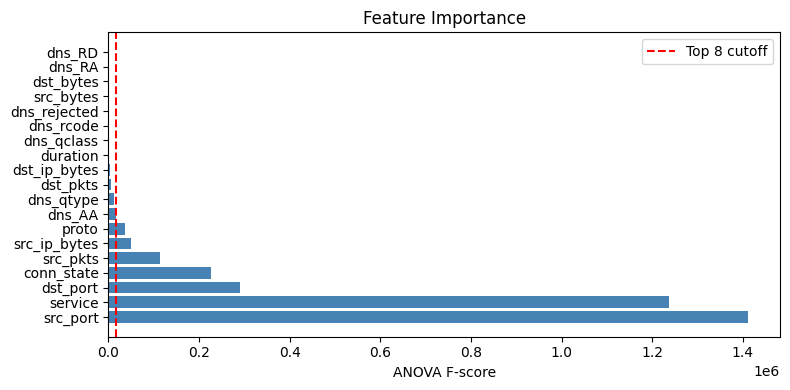

Selected: ['src_port', 'service', 'dst_port', 'conn_state', 'src_pkts', 'src_ip_bytes', 'proto', 'dns_AA']


In [8]:
N_QUBITS = 8
f_scores, _ = f_classif(X, df['type'])
feature_importance = (
    pd.DataFrame({'feature': X.columns, 'f_score': f_scores})
    .sort_values('f_score', ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(feature_importance['feature'], feature_importance['f_score'], color='steelblue')
ax.axvline(x=feature_importance.iloc[N_QUBITS-1]['f_score'], color='red', linestyle='--', label=f'Top {N_QUBITS} cutoff')
ax.set_xlabel('ANOVA F-score')
ax.set_title('Feature Importance')
ax.legend()
plt.tight_layout()
plt.show()

top_features = feature_importance.head(N_QUBITS)['feature'].tolist()
print(f"Selected: {top_features}")

## 6. Balance Classes

In [9]:
X = X[top_features]
y = df['type']
min_size = y.value_counts().min()
print(f"Undersampling to {min_size} samples per class")

dfs = []
for cls in y.unique():
    idx = y[y == cls].index
    if len(idx) > min_size:
        idx = idx[:min_size]
    dfs.append(pd.concat([X.loc[idx], y.loc[idx]], axis=1))
df_balanced = pd.concat(dfs, ignore_index=True).sample(frac=1, random_state=42)
X_bal = df_balanced[top_features]
y_bal = df_balanced['type']

print(f"Balanced dataset: {df_balanced.shape}")
y_bal.value_counts()

Undersampling to 35168 samples per class
Balanced dataset: (105504, 9)


type
injection    35168
normal       35168
dos          35168
Name: count, dtype: int64

## 7. Normalize to [0, π] for Angle Encoding

In [10]:
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = pd.DataFrame(scaler.fit_transform(X_bal), columns=top_features)
X_scaled.describe().loc[['min', 'max']].round(4)

,src_port,service,dst_port,conn_state,src_pkts,src_ip_bytes,proto,dns_AA
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
max,3.1416,3.1416,3.1416,3.1416,3.1416,3.1416,3.1416,3.1416


## 8. Visualizations

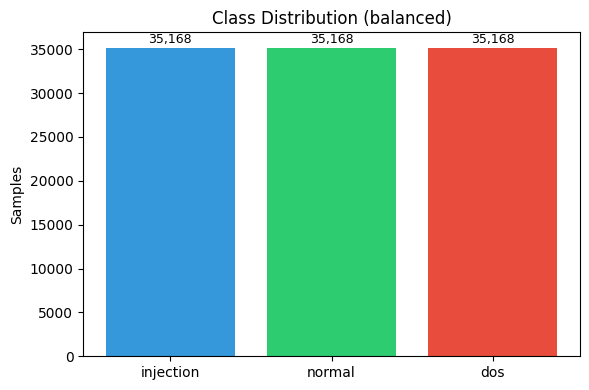

In [11]:
colors = {'normal': '#2ecc71', 'dos': '#e74c3c', 'injection': '#3498db'}
counts = y_bal.value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=[colors[t] for t in counts.index])
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
            f'{val:,}', ha='center', fontsize=9)
ax.set_title('Class Distribution (balanced)')
ax.set_ylabel('Samples')
plt.tight_layout()
plt.savefig(FIGURES / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

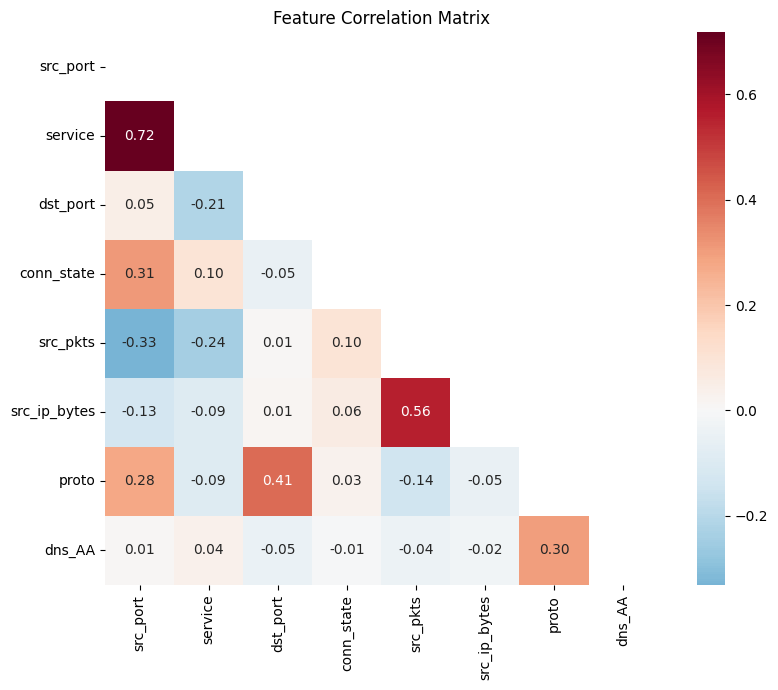

In [12]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(X_scaled.corr(), mask=np.triu(np.ones((N_QUBITS, N_QUBITS), dtype=bool)),
            cmap='RdBu_r', center=0, square=True, annot=True, fmt='.2f', ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(FIGURES / 'correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Train / Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(y_train.value_counts())

Train: (84403, 8)  |  Test: (21101, 8)
type
dos          28135
injection    28134
normal       28134
Name: count, dtype: int64


## 10. Zero-Day Split
Train on **normal + dos**, test on **injection** (unseen attack type).

In [14]:
mask_tr = y_bal.isin(['normal', 'dos'])
X_train_zd = X_scaled[mask_tr]
y_train_zd = y_bal[mask_tr].map({'normal': 0, 'dos': 1})
X_test_zd = X_scaled[y_bal == 'injection']
y_test_zd = pd.Series(np.ones(X_test_zd.shape[0], dtype=int))
print(f"Zero-day — Train: {X_train_zd.shape}  |  Test (injection): {X_test_zd.shape}")

Zero-day — Train: (70336, 8)  |  Test (injection): (35168, 8)


/var/folders/x1/q4l6n46n167g3rk91sykmrzw0000gn/T/ipykernel_26315/1619624846.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_train_zd = X_scaled[mask_tr]
/var/folders/x1/q4l6n46n167g3rk91sykmrzw0000gn/T/ipykernel_26315/1619624846.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_test_zd = X_scaled[y_bal == 'injection']


## 11. Quantum Subsample
Quantum simulation on CPU is slow — subsample for circuit experiments.

In [15]:
X_train_q = X_train.sample(n=500, random_state=42)
y_train_q = y_train.loc[X_train_q.index]
X_test_q  = X_test.sample(n=min(200, len(X_test)), random_state=42)
y_test_q  = y_test.loc[X_test_q.index]
print(f"Quantum subsample — Train: {X_train_q.shape}  |  Test: {X_test_q.shape}")

KeyError: '[80508, 65533, 63646, 47713, 16927, 3717, 60290, 43649, 83671, 48373, 63934, 50175, 3289, 3805, 59760, 7425, 41679, 93203, 3362, 11266, 61251, 32194, 48076, 41199, 70616, 51280, 89067, 70001, 83191, 18631, 72950, 28054, 8931, 34702, 86547, 96197, 36961, 56212, 43531, 60542, 70052, 35725, 24127, 40385, 3610, 86177, 36956, 34326, 71657, 90043, 78996, 11633, 17679, 8728, 98459, 73310, 16112, 56666, 56444, 38526, 69680, 48017, 40930, 68357, 75620, 95059, 44412, 99278, 58707, 102555, 90398, 63521, 44562, 4244, 26354, 7181, 67197, 7390, 52467, 49024, 37262, 16559, 94068, 68295, 4532, 8472, 105000, 38066, 34615, 968, 69069, 61030, 74145, 83840, 14070, 55636, 16361, 36326, 63617] not in index'

## 12. Save

In [ ]:
X_train.to_csv(DATA / 'X_train.csv', index=False)
X_test.to_csv(DATA / 'X_test.csv', index=False)
y_train.to_csv(DATA / 'y_train.csv', index=False)
y_test.to_csv(DATA / 'y_test.csv', index=False)
X_train_q.to_csv(DATA / 'X_train_quantum.csv', index=False)
y_train_q.to_csv(DATA / 'y_train_quantum.csv', index=False)
X_train_zd.to_csv(DATA / 'X_train_zeroday.csv', index=False)
y_train_zd.to_csv(DATA / 'y_train_zeroday.csv', index=False)
X_test_zd.to_csv(DATA / 'X_test_zeroday.csv', index=False)
y_test_zd.to_csv(DATA / 'y_test_zeroday.csv', index=False)
print("Done. All splits saved to data/")